<a href="https://colab.research.google.com/github/munawirmt/EDA-Timeseries-models-in-ML/blob/main/ARIMA_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ARIMA Timeseres model prediction with TESLA dataset**


In [1]:
## install libreries
import pandas as pd
import yfinance as yf

In [4]:
## load dataset
df=yf.download('TSLA',start='2020-01-01',end='2026-09-19')
df

/tmp/ipykernel_907/902130872.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download('TSLA',start='2020-01-01',end='2026-09-19')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500
...,...,...,...,...,...
2026-09-14,358.970001,367.730011,357.040009,359.779999,32477200
2026-09-15,356.579987,362.390015,354.049988,358.750000,30317700


In [5]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


<Axes: xlabel='Date'>

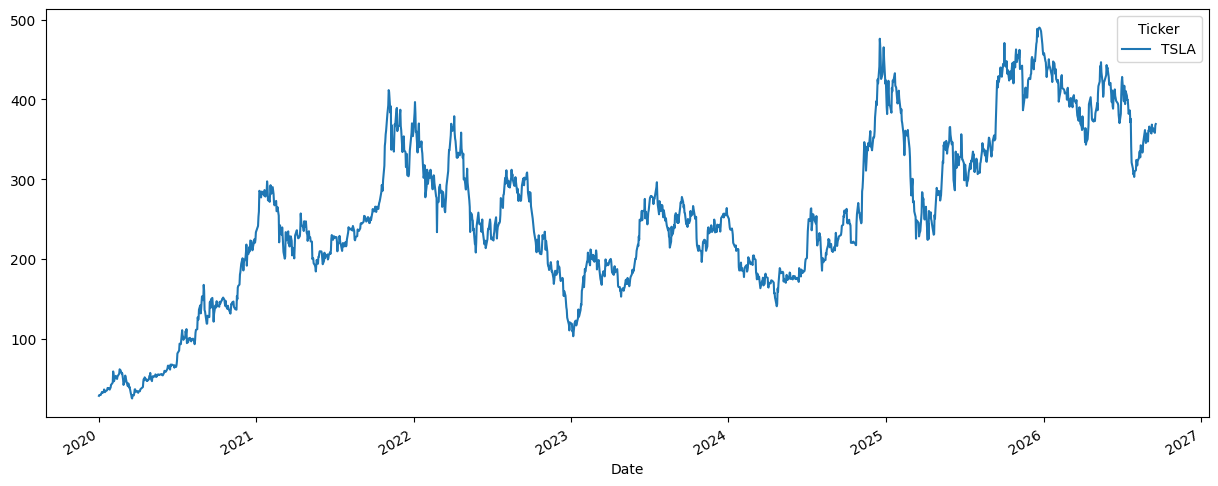

In [7]:
## simple moving average
df['Open'].plot(figsize=(15,6))

<Axes: xlabel='Date'>

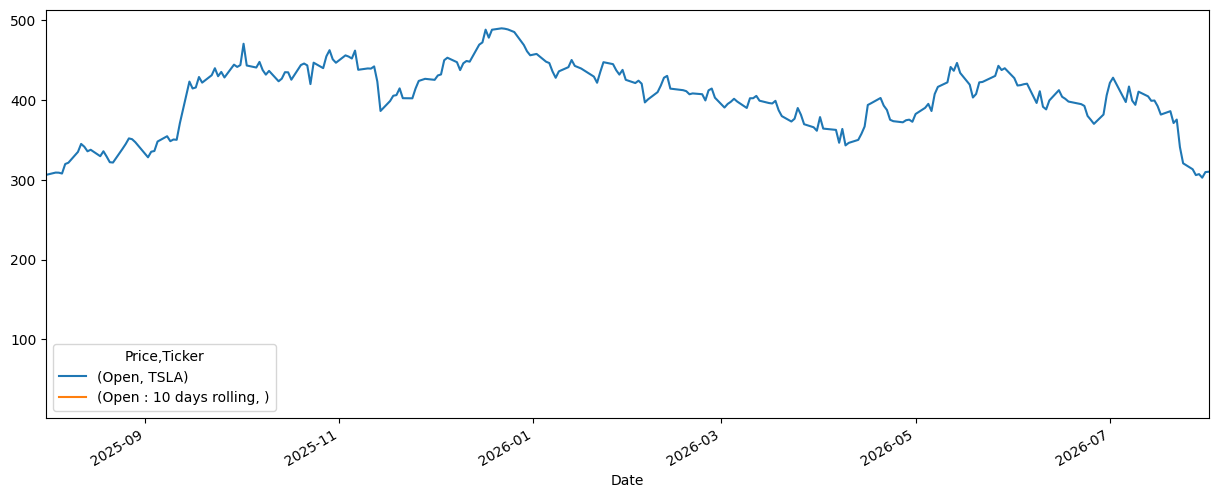

In [11]:
df['Open : 10 days rolling']=df['Open'].rolling(window=10,min_periods=1).mean()
df[['Open','Open : 10 days rolling']].plot(xlim=['2025-08-01','2026-08-01'],figsize=(15,6))

<Axes: xlabel='Date'>

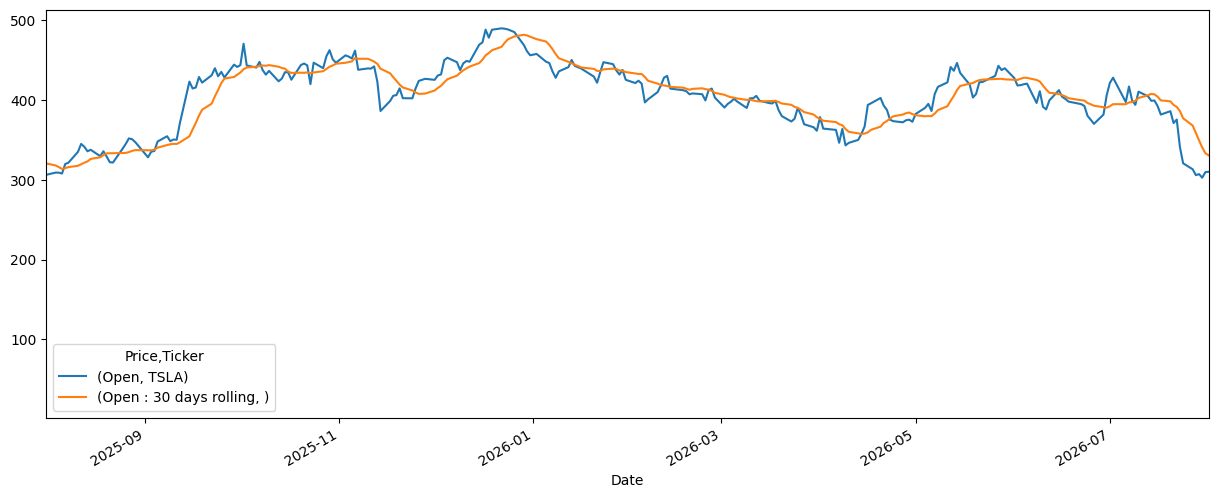

In [12]:
df['Open : 30 days rolling']=df['Open'].rolling(window=10,min_periods=1).mean()
df[['Open','Open : 30 days rolling']].plot(xlim=['2025-08-01','2026-08-01'],figsize=(15,6))

<Axes: xlabel='Date'>

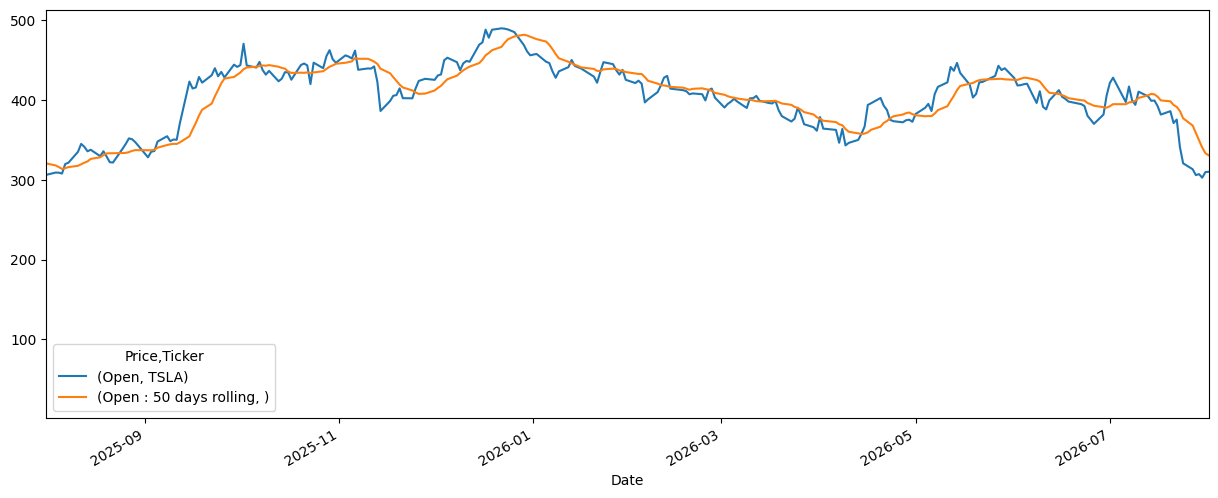

In [13]:
df['Open : 50 days rolling']=df['Open'].rolling(window=10,min_periods=1).mean()
df[['Open','Open : 50 days rolling']].plot(xlim=['2025-08-01','2026-08-01'],figsize=(15,6))

<Axes: xlabel='Date'>

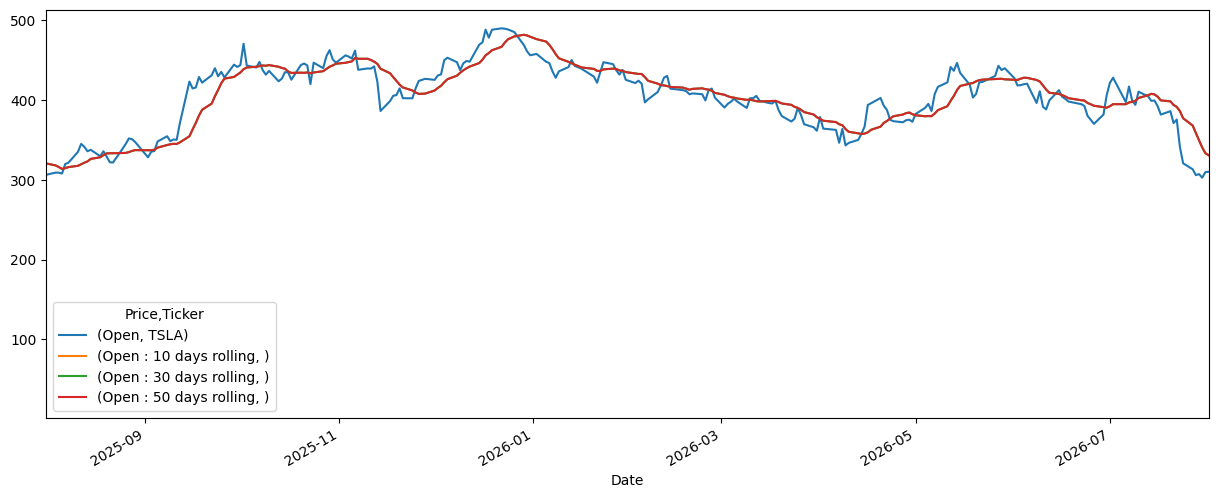

In [15]:
df[['Open','Open : 10 days rolling','Open : 30 days rolling','Open : 50 days rolling']].plot(xlim=['2025-08-01','2026-08-01'],figsize=(15,6))

In [17]:
# Check how many valid (non-null) values exist in your date range
print(df.loc['2025-08-01':'2026-08-01', ['Open','Open : 10 days rolling','Open : 30 days rolling','Open : 50 days rolling']].count())


Price                   Ticker
Open                    TSLA      251
Open : 10 days rolling              0
Open : 30 days rolling            251
Open : 50 days rolling            251
dtype: int64


<Axes: xlabel='Date'>

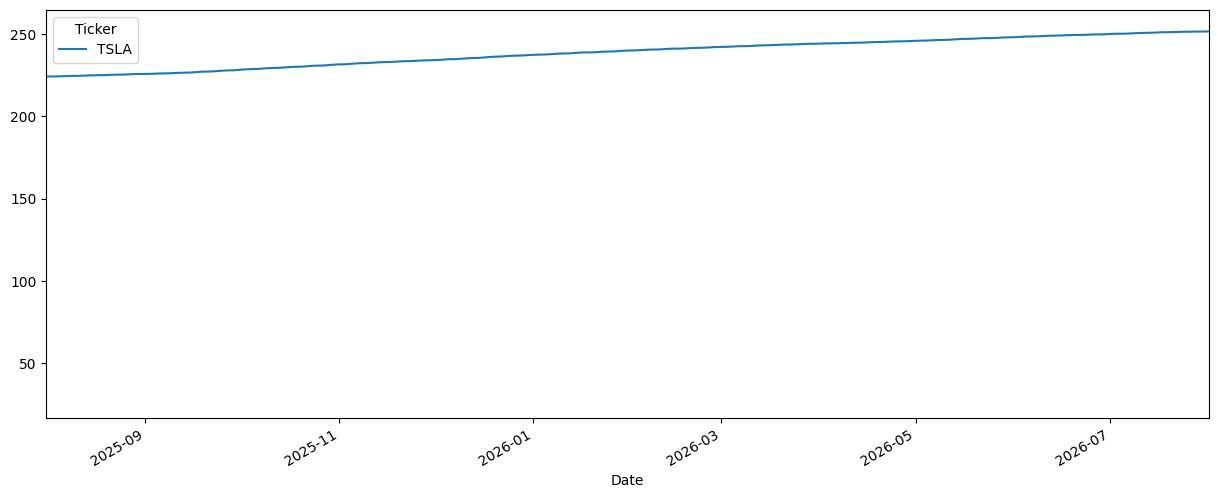

In [20]:
## expanding
## CMA (cumulative moving average)
df['Open'].expanding(min_periods=1).mean().plot(xlim=['2025-08-01','2026-08-01'],figsize=(15,6))

<Axes: xlabel='Date'>

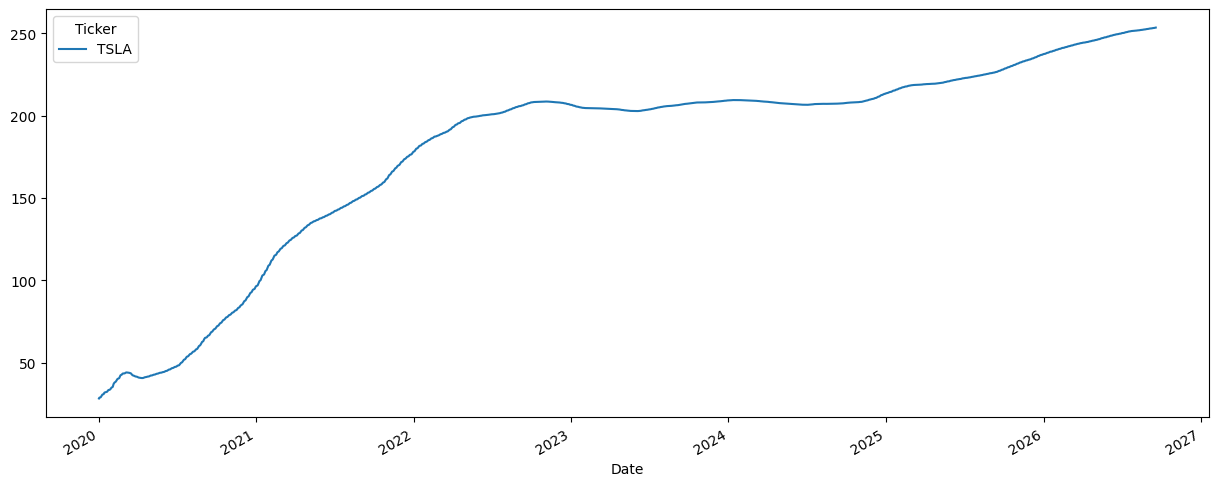

In [22]:
df['Open'].expanding().mean().plot(figsize=(15,6))

<Axes: xlabel='Date'>

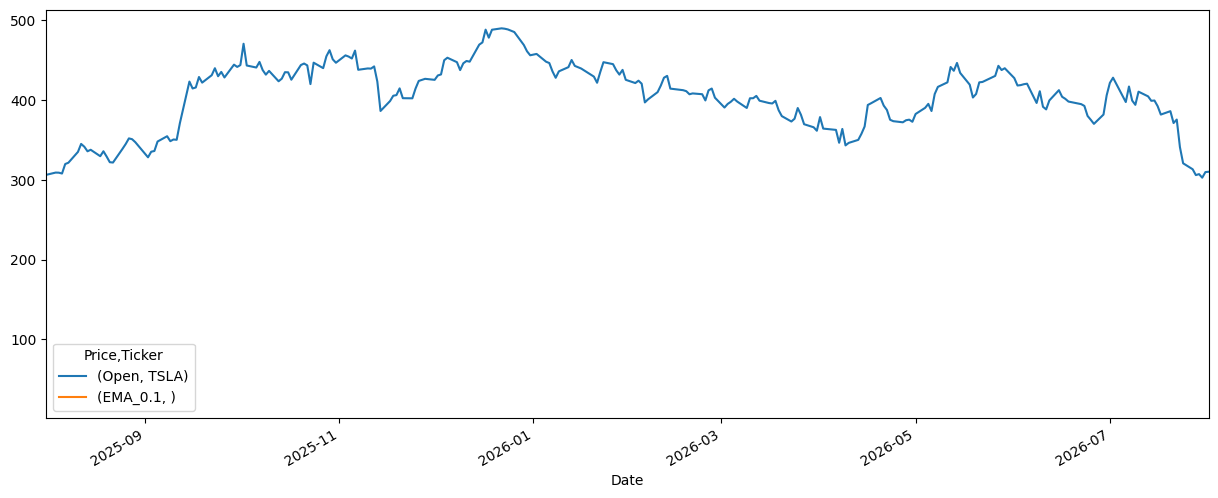

In [25]:
## EWMA (exponential moving average)
## ema tesla shares
## let smoothing factor is 0.1
df['EMA_0.1']=df['Open'].ewm(alpha=0.1,adjust=False).mean()
df[['Open','EMA_0.1']].plot(xlim=['2025-08-01','2026-08-01'],figsize=(15,6))

<Axes: xlabel='Date'>

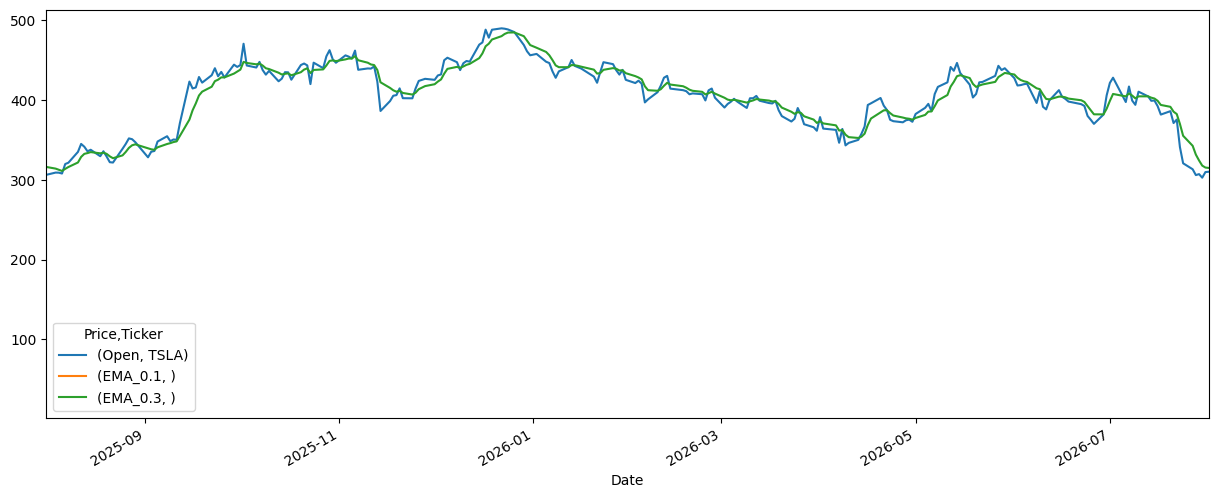

In [26]:
df['EMA_0.3']=df['Open'].ewm(alpha=0.3,adjust=False).mean()
df[['Open','EMA_0.1','EMA_0.3']].plot(xlim=['2025-08-01','2026-08-01'],figsize=(15,6))

<Axes: xlabel='Date'>

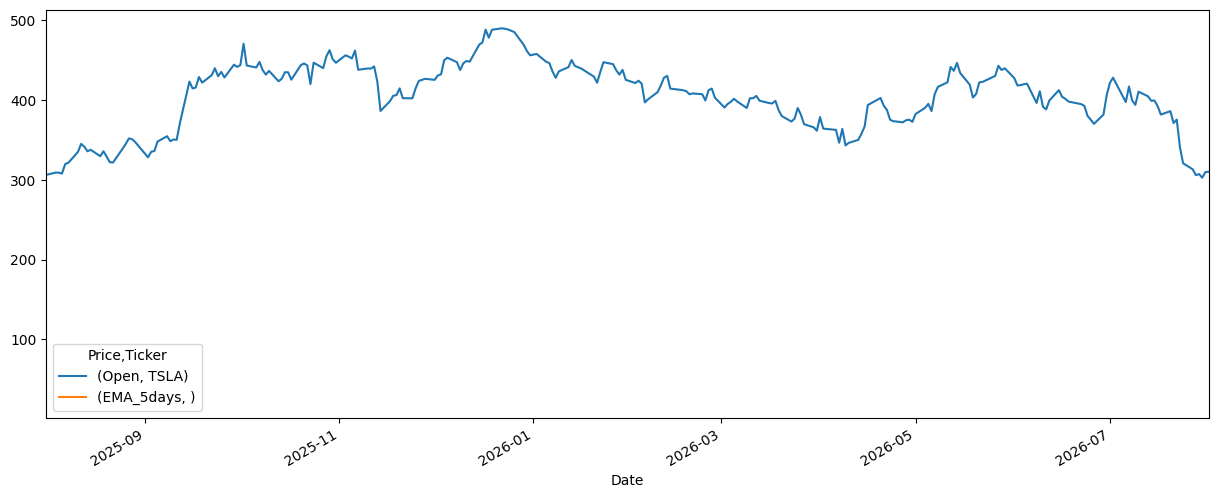

In [39]:
df['EMA_5days']=df['Open'].ewm(span=5).mean()
df[['Open','EMA_5days']].plot(xlim=['2025-08-01','2026-08-01'],figsize=(15,6))